
**ACT (Action Chunking with Transformers) — UR5 Pick and Place**

Using HuggingFace LeRobot framework



In [5]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# install dependencies
!pip install lerobot h5py numpy torch matplotlib -q

In [7]:
# Clone LeRobot
#LeRobot must be installed from source for ACT training
!git clone https://github.com/huggingface/lerobot.git /content/lerobot
!pip install -e /content/lerobot -q

Cloning into '/content/lerobot'...
remote: Enumerating objects: 52136, done.
remote: Counting objects: 100% (707/707), done.
remote: Compressing objects: 100% (261/261), done.
remote: Total 52136 (delta 558), reused 465 (delta 438), pack-reused 51429 (from 3)
Receiving objects: 100% (52136/52136), 243.64 MiB | 14.92 MiB/s, done.
Resolving deltas: 100% (33288/33288), done.
Filtering content: 100% (50/50), 69.11 MiB | 3.97 MiB/s, done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for lerobot (pyproject.toml) ... done


In [7]:
# Imports & Config
import os
import sys
import glob
import shutil
import json
from pathlib import Path

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

# ── update these paths to match your Google Drive layout ──────
HDF5_DIR   = '/content/drive/MyDrive/imitation_learning_training/pick_and_place_imitation_data'
LEROBOT_DIR = '/content/lerobot_dataset'   # where converted dataset will live
SAVE_DIR   = '/content/drive/MyDrive/imitation_learning_training/act_checkpoints'

# ── task / observation config ─────────────────────────────────
OBS_DIM    = 17    # 6 joints + 7 ee pose + 3 cube pos + 1 gripper
ACTION_DIM = 6     # target joint angles
FPS        = 3     # effective recording rate (ZMQ overhead ~3Hz)

# ── ACT hyperparameters ───────────────────────────────────────
CHUNK_SIZE = 10    # action chunk size — how many steps ACT predicts at once
BATCH_SIZE = 64
EPOCHS     = 200
LR         = 1e-4

os.makedirs(SAVE_DIR, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'HDF5 source : {HDF5_DIR}')
print(f'LeRobot dir : {LEROBOT_DIR}')

Device: cuda
HDF5 source : /content/drive/MyDrive/imitation_learning_training/pick_and_place_imitation_data
LeRobot dir : /content/lerobot_dataset


In [8]:
# Verify HDF5 files
files = sorted(
    glob.glob(f'{HDF5_DIR}/Pick_place_episode_*.hdf5'),
    key=lambda x: int(os.path.basename(x).split('_')[-1].replace('.hdf5', ''))
)
print(f'Found {len(files)} HDF5 episodes')

# quick sanity check on first file
with h5py.File(files[0], 'r') as f:
    print(f'\nEpisode 1 keys : {list(f.keys())}')
    for k in f.keys():
        print(f'  {k}: shape={f[k].shape}  dtype={f[k].dtype}')

Found 100 HDF5 episodes

Episode 1 keys : ['actions', 'cube_position', 'end_effector_pose', 'gripper_state', 'joint_positions', 'timestamps']
  actions: shape=(93, 6)  dtype=float64
  cube_position: shape=(93, 3)  dtype=float64
  end_effector_pose: shape=(93, 7)  dtype=float64
  gripper_state: shape=(93,)  dtype=float64
  joint_positions: shape=(93, 6)  dtype=float64
  timestamps: shape=(93,)  dtype=float64


In [9]:
# Convert HDF5 → LeRobot format
# LeRobot expects data in a specific structure:
#   lerobot_dataset/
#     meta/
#       info.json          ← dataset metadata
#       episodes.jsonl     ← per-episode metadata
#     data/
#       episode_000000/
#         frame_000000.pt  ← one .pt file per timestep
#         frame_000001.pt
#         ...
#       episode_000001/
#         ...

def convert_hdf5_to_lerobot(hdf5_files, out_dir, obs_dim, action_dim, fps):
    """
    Convert raw HDF5 episodes to LeRobot dataset format.
    Each timestep is saved as a .pt dict containing observation and action.
    """
    out_dir = Path(out_dir)
    data_dir = out_dir / 'data'
    meta_dir = out_dir / 'meta'
    data_dir.mkdir(parents=True, exist_ok=True)
    meta_dir.mkdir(parents=True, exist_ok=True)

    episodes_meta = []
    total_frames  = 0

    for ep_idx, fpath in enumerate(hdf5_files):
        with h5py.File(fpath, 'r') as f:
            jp   = f['joint_positions'][:]    # (T, 6)
            ac   = f['actions'][:]            # (T, 6)
            cube = f['cube_position'][:]      # (T, 3)
            ee   = f['end_effector_pose'][:]  # (T, 7)
            grip = f['gripper_state'][:]      # (T,)

        T = jp.shape[0]

        # build observation vector (T, 17)
        obs = np.concatenate([jp, ee, cube, grip[:, None]], axis=1)

        ep_dir = data_dir / f'episode_{ep_idx:06d}'
        ep_dir.mkdir(exist_ok=True)

        for t in range(T):
            frame = {
                'observation.state': torch.tensor(obs[t], dtype=torch.float32),
                'action':            torch.tensor(ac[t],  dtype=torch.float32),
                'episode_index':     torch.tensor(ep_idx, dtype=torch.long),
                'frame_index':       torch.tensor(t,      dtype=torch.long),
                'timestamp':         torch.tensor(t / fps, dtype=torch.float32),
                'next.done':         torch.tensor(t == T - 1, dtype=torch.bool),
                'is_first':          torch.tensor(t == 0, dtype=torch.bool),
                'is_last':           torch.tensor(t == T - 1, dtype=torch.bool),
            }
            torch.save(frame, ep_dir / f'frame_{t:06d}.pt')

        episodes_meta.append({
            'episode_index': ep_idx,
            'tasks':         ['pick_and_place'],
            'length':        T,
        })
        total_frames += T

        if (ep_idx + 1) % 10 == 0:
            print(f'  Converted {ep_idx + 1}/{len(hdf5_files)} episodes...')

    # write meta/info.json
    info = {
        'codebase_version': 'v2.0',
        'robot_type':       'ur5',
        'fps':              fps,
        'total_episodes':   len(hdf5_files),
        'total_frames':     total_frames,
        'features': {
            'observation.state': {
                'dtype': 'float32',
                'shape': [obs_dim],
                'names': (
                    [f'joint_{i}' for i in range(6)] +
                    ['ee_x','ee_y','ee_z','ee_qx','ee_qy','ee_qz','ee_qw'] +
                    ['cube_x','cube_y','cube_z'] +
                    ['gripper']
                )
            },
            'action': {
                'dtype':  'float32',
                'shape':  [action_dim],
                'names':  [f'joint_{i}_target' for i in range(action_dim)]
            }
        }
    }
    with open(meta_dir / 'info.json', 'w') as f:
        json.dump(info, f, indent=2)

    # write meta/episodes.jsonl
    with open(meta_dir / 'episodes.jsonl', 'w') as f:
        for ep in episodes_meta:
            f.write(json.dumps(ep) + '\n')

    print(f'\nConversion complete.')
    print(f'  Episodes : {len(hdf5_files)}')
    print(f'  Frames   : {total_frames}')
    print(f'  Saved to : {out_dir}')
    return total_frames


# run conversion (skip if already done)
if not Path(LEROBOT_DIR).exists():
    print('Converting HDF5 → LeRobot format...')
    convert_hdf5_to_lerobot(files, LEROBOT_DIR, OBS_DIM, ACTION_DIM, FPS)
else:
    print('LeRobot dataset already exists, skipping conversion.')

Converting HDF5 → LeRobot format...
  Converted 10/100 episodes...
  Converted 20/100 episodes...
  Converted 30/100 episodes...
  Converted 40/100 episodes...
  Converted 50/100 episodes...
  Converted 60/100 episodes...
  Converted 70/100 episodes...
  Converted 80/100 episodes...
  Converted 90/100 episodes...
  Converted 100/100 episodes...

Conversion complete.
  Episodes : 100
  Frames   : 10014
  Saved to : /content/lerobot_dataset


In [10]:
# PyTorch Dataset
from torch.utils.data import Dataset, DataLoader, random_split

class UR5LeRobotDataset(Dataset):
    """
    Loads the converted LeRobot dataset with action chunking.

    For each timestep t, returns:
        obs    : observation at t              (obs_dim,)
        actions: next chunk_size actions       (chunk_size, action_dim)

    If fewer than chunk_size steps remain, the last action is repeated
    to pad — this is the standard ACT padding strategy.
    """
    def __init__(self, episode_dirs, chunk_size=10):

        self.chunk_size = chunk_size
        self.frames = []

        for ep_dir in episode_dirs:

            frame_files = sorted(ep_dir.glob('frame_*.pt'))
            T = len(frame_files)

            for t in range(T):
                self.frames.append((ep_dir, t, T))

        print(f'Dataset: {len(self.frames)} timesteps '
              f'with chunk_size={chunk_size}')

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        ep_dir, t, T = self.frames[idx]

        # load observation at t
        frame = torch.load(ep_dir / f'frame_{t:06d}.pt', weights_only=True)
        obs   = frame['observation.state']   # (obs_dim,)

        # load action chunk [t, t+chunk_size)
        actions = []
        for k in range(self.chunk_size):
            step = min(t + k, T - 1)   # clamp to last frame for padding
            f    = torch.load(ep_dir / f'frame_{step:06d}.pt', weights_only=True)
            actions.append(f['action'])
        actions = torch.stack(actions)   # (chunk_size, action_dim)

        return obs, actions

In [14]:
#  Build dataloaders

# ── CELL 8 REPLACEMENT: Load everything into memory ──────────

print("Loading all episodes into memory...")

all_obs_list = []
all_act_list = []

for ep_idx, fpath in enumerate(files):

    with h5py.File(fpath, 'r') as f:
        jp   = f['joint_positions'][:]
        ac   = f['actions'][:]
        cube = f['cube_position'][:]
        ee   = f['end_effector_pose'][:]
        grip = f['gripper_state'][:]

    # build observation vector
    obs = np.concatenate(
        [jp, ee, cube, grip[:, None]],
        axis=1
    )  # (T, 17)

    all_obs_list.append(obs)
    all_act_list.append(ac)

# stack entire dataset into RAM
all_obs = torch.tensor(
    np.concatenate(all_obs_list),
    dtype=torch.float32
)

all_ac = torch.tensor(
    np.concatenate(all_act_list),
    dtype=torch.float32
)

# episode boundaries
ep_lengths   = [len(o) for o in all_obs_list]
ep_start_idx = np.cumsum([0] + ep_lengths[:-1])

print(f"Loaded {all_obs.shape[0]:,} timesteps into RAM")
print(f"obs shape: {all_obs.shape}")
print(f"act shape: {all_ac.shape}")


# ── Dataset ──────────────────────────────────────────────────

from torch.utils.data import Dataset, DataLoader

class InMemoryACTDataset(Dataset):

    def __init__(
        self,
        obs_tensor,
        act_tensor,
        ep_starts,
        ep_lengths,
        ep_indices,
        chunk_size
    ):

        self.obs        = obs_tensor
        self.act        = act_tensor
        self.chunk_size = chunk_size

        self.samples = []

        for ep_i in ep_indices:

            start  = ep_starts[ep_i]
            length = ep_lengths[ep_i]
            end    = start + length

            for t in range(start, end):
                self.samples.append((t, end))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        t, ep_end = self.samples[idx]

        # current observation
        obs = self.obs[t]

        # chunk indices
        chunk_indices = torch.arange(
            t,
            min(t + self.chunk_size, ep_end)
        )

        # ACT padding strategy
        if len(chunk_indices) < self.chunk_size:

            pad = torch.full(
                (self.chunk_size - len(chunk_indices),),
                ep_end - 1,
                dtype=torch.long
            )

            chunk_indices = torch.cat([chunk_indices, pad])

        # action chunk
        actions = self.act[chunk_indices]

        return obs, actions


# ── Episode-level split ──────────────────────────────────────

n_eps = len(files)

np.random.seed(42)

shuffled = np.random.permutation(n_eps)

split_idx = int(n_eps * 0.9)

train_eps = shuffled[:split_idx].tolist()
val_eps   = shuffled[split_idx:].tolist()


# ── Build datasets ───────────────────────────────────────────

train_ds = InMemoryACTDataset(
    all_obs,
    all_ac,
    ep_start_idx,
    ep_lengths,
    train_eps,
    CHUNK_SIZE
)

val_ds = InMemoryACTDataset(
    all_obs,
    all_ac,
    ep_start_idx,
    ep_lengths,
    val_eps,
    CHUNK_SIZE
)

print(f"Train samples: {len(train_ds):,}")
print(f"Val samples  : {len(val_ds):,}")


# ── Compute normalization stats from TRAIN ONLY ──────────────

print("Computing normalization stats...")

train_indices = [s[0] for s in train_ds.samples]

train_obs_raw = all_obs[train_indices]
train_act_raw = all_ac[train_indices]

obs_mean = train_obs_raw.mean(0)
obs_std  = train_obs_raw.std(0) + 1e-8

act_mean = train_act_raw.mean(0)
act_std  = train_act_raw.std(0) + 1e-8


# ── Save stats for inference ─────────────────────────────────

np.save(f'{SAVE_DIR}/act_obs_mean.npy', obs_mean.numpy())
np.save(f'{SAVE_DIR}/act_obs_std.npy',  obs_std.numpy())

np.save(f'{SAVE_DIR}/act_act_mean.npy', act_mean.numpy())
np.save(f'{SAVE_DIR}/act_act_std.npy',  act_std.numpy())

torch.save({
    'obs_mean': obs_mean,
    'obs_std':  obs_std,
    'act_mean': act_mean,
    'act_std':  act_std,
}, f'{SAVE_DIR}/normalization_stats.pt')


# ── Normalized wrapper ───────────────────────────────────────

class NormalisedDataset(Dataset):

    def __init__(
        self,
        base,
        obs_mean,
        obs_std,
        act_mean,
        act_std
    ):

        self.base = base

        self.obs_mean = obs_mean
        self.obs_std  = obs_std

        self.act_mean = act_mean
        self.act_std  = act_std

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):

        obs, actions = self.base[idx]

        obs = (obs - self.obs_mean) / self.obs_std

        actions = (
            (actions - self.act_mean)
            / self.act_std
        )

        return obs, actions


train_norm = NormalisedDataset(
    train_ds,
    obs_mean,
    obs_std,
    act_mean,
    act_std
)

val_norm = NormalisedDataset(
    val_ds,
    obs_mean,
    obs_std,
    act_mean,
    act_std
)


# ── DataLoaders ──────────────────────────────────────────────

PIN = DEVICE == 'cuda'

train_loader = DataLoader(
    train_norm,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN
)

val_loader = DataLoader(
    val_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN
)

print(f'Train: {len(train_norm):,}')
print(f'Val  : {len(val_norm):,}')



Loading all episodes into memory...
Loaded 10,014 timesteps into RAM
obs shape: torch.Size([10014, 17])
act shape: torch.Size([10014, 6])
Train samples: 9,009
Val samples  : 1,005
Computing normalization stats...
Train: 9,009
Val  : 1,005


In [15]:
# ACT Model
# ACT architecture:
#   Encoder: transformer that encodes the observation
#   Decoder: transformer that predicts a chunk of actions
#   The key idea: predict CHUNK_SIZE actions at once instead of 1
#   This reduces compounding errors vs standard BC

import torch.nn as nn
import math


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class ACTPolicy(nn.Module):
    """
    Simplified ACT: state-only (no images), encoder-decoder transformer.

    Encoder: encodes observation → latent context
    Decoder: cross-attends to context, autoregressively predicts action chunk

    This is a faithful state-only adaptation of the ACT architecture
    from Zhao et al. 2023 (https://arxiv.org/abs/2304.13705)
    """
    def __init__(
        self,
        obs_dim    = OBS_DIM,
        action_dim = ACTION_DIM,
        chunk_size = CHUNK_SIZE,
        d_model    = 256,
        nhead      = 8,
        num_encoder_layers = 4,
        num_decoder_layers = 4,
        dim_feedforward    = 1024,
        dropout    = 0.1,
    ):
        super().__init__()
        self.chunk_size = chunk_size
        self.d_model    = d_model

        # project observation into model dimension
        self.obs_proj = nn.Sequential(
            nn.Linear(obs_dim, d_model),
            nn.LayerNorm(d_model),
        )

        # learnable action query tokens — one per chunk step
        self.action_queries = nn.Embedding(chunk_size, d_model)

        # positional encoding
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        # transformer encoder (processes observation)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_encoder_layers)

        # transformer decoder (generates action chunk)
        dec_layer = nn.TransformerDecoderLayer(
            d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_decoder_layers)

        # project decoder output → action
        self.action_head = nn.Linear(d_model, action_dim)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, obs):
        """
        obs : (B, obs_dim)
        returns: (B, chunk_size, action_dim)
        """
        B = obs.size(0)

        # encode observation → (B, 1, d_model)
        obs_emb = self.obs_proj(obs).unsqueeze(1)
        memory  = self.encoder(obs_emb)   # (B, 1, d_model)

        # action queries → (B, chunk_size, d_model)
        idx      = torch.arange(self.chunk_size, device=obs.device)
        queries  = self.action_queries(idx).unsqueeze(0).expand(B, -1, -1)
        queries  = self.pos_enc(queries)

        # decode → (B, chunk_size, d_model)
        decoded  = self.decoder(queries, memory)

        # project → (B, chunk_size, action_dim)
        actions  = self.action_head(decoded)
        return actions


model = ACTPolicy().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'ACT parameters: {total_params:,}')

ACT parameters: 7,382,022


In [16]:
# Training
import torch
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

criterion = nn.SmoothL1Loss(beta=0.01)

train_losses = []
val_losses = []
smoothness_losses = []

best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ─────────────────────────────────────
    model.train()

    batch_losses = []
    smoothness_batch_losses = []

    for obs, actions in train_loader:

        obs = obs.to(DEVICE)
        actions = actions.to(DEVICE)

        pred = model(obs)

        # main prediction loss
        mse_loss = criterion(pred, actions)

        # smoothness regularization
        delta = pred[:, 1:] - pred[:, :-1]
        smoothness_loss = delta.abs().mean()

        # total loss
        loss = mse_loss + 0.01 * smoothness_loss

        optimizer.zero_grad()

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_losses.append(loss.item())
        smoothness_batch_losses.append(
            smoothness_loss.item()
        )

    # ── VALIDATE ──────────────────────────────────
    model.eval()

    val_batch_losses = []

    with torch.no_grad():

        for obs, actions in val_loader:

            obs = obs.to(DEVICE)
            actions = actions.to(DEVICE)

            pred = model(obs)

            mse_loss = criterion(pred, actions)

            delta = pred[:, 1:] - pred[:, :-1]
            smoothness_loss = delta.abs().mean()

            val_loss = mse_loss + 0.01 * smoothness_loss

            val_batch_losses.append(val_loss.item())

    # ── EPOCH METRICS ─────────────────────────────
    train_loss = np.mean(batch_losses)
    val_loss = np.mean(val_batch_losses)

    epoch_smoothness = np.mean(
        smoothness_batch_losses
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    smoothness_losses.append(epoch_smoothness)

    scheduler.step()

    # ── SAVE BEST MODEL ───────────────────────────
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'obs_dim': OBS_DIM,
            'action_dim': ACTION_DIM,
            'chunk_size': CHUNK_SIZE,
            'd_model': 256,
        }, f'{SAVE_DIR}/act_best.pth')

    # ── LOGGING ───────────────────────────────────
    if epoch % 20 == 0 or epoch == 1:

        print(
            f'Epoch {epoch:3d}/{EPOCHS} | '
            f'train={train_loss:.6f} | '
            f'val={val_loss:.6f} | '
            f'smooth={epoch_smoothness:.6f} | '
            f'best_val={best_val_loss:.6f}'
        )

print(f'\nDone. Best val loss: {best_val_loss:.6f}')

Epoch   1/200 | train=0.450379 | val=0.234442 | smooth=0.383387 | best_val=0.234442
Epoch  20/200 | train=0.092654 | val=0.101161 | smooth=0.120516 | best_val=0.089827
Epoch  40/200 | train=0.072401 | val=0.053789 | smooth=0.104119 | best_val=0.053789
Epoch  60/200 | train=0.061270 | val=0.054552 | smooth=0.097478 | best_val=0.045826
Epoch  80/200 | train=0.053788 | val=0.048240 | smooth=0.094617 | best_val=0.039896
Epoch 100/200 | train=0.049576 | val=0.034545 | smooth=0.092624 | best_val=0.034545
Epoch 120/200 | train=0.044913 | val=0.036092 | smooth=0.091211 | best_val=0.032935
Epoch 140/200 | train=0.041970 | val=0.033804 | smooth=0.090354 | best_val=0.030262
Epoch 160/200 | train=0.040171 | val=0.031964 | smooth=0.090140 | best_val=0.030262
Epoch 180/200 | train=0.038889 | val=0.030476 | smooth=0.089802 | best_val=0.030161
Epoch 200/200 | train=0.038811 | val=0.030193 | smooth=0.089917 | best_val=0.029922

Done. Best val loss: 0.029922


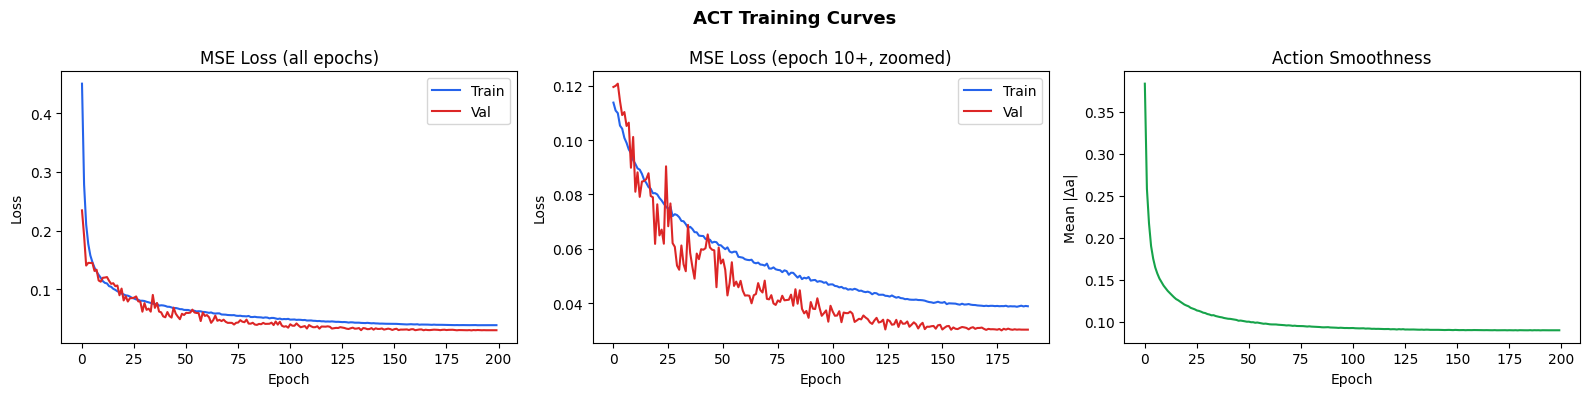

In [17]:

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('ACT Training Curves', fontsize=13, fontweight='bold')

# ── Train / Val loss ─────────────────────────────
axes[0].plot(train_losses, label='Train', color='#2563EB')
axes[0].plot(val_losses,   label='Val',   color='#DC2626')
axes[0].set_title('MSE Loss (all epochs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# ── Zoomed loss ──────────────────────────────────
axes[1].plot(train_losses[10:], label='Train', color='#2563EB')
axes[1].plot(val_losses[10:],   label='Val',   color='#DC2626')
axes[1].set_title('MSE Loss (epoch 10+, zoomed)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# ── Smoothness loss ──────────────────────────────
axes[2].plot(smoothness_losses, color='#16A34A')
axes[2].set_title('Action Smoothness')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Mean |Δa|')

plt.tight_layout()

plt.savefig(
    f'{SAVE_DIR}/act_training_curves.png',
    dpi=130,
    bbox_inches='tight'
)
plt.show()

In [18]:
# Evaluate on val set
ckpt = torch.load(f'{SAVE_DIR}/act_best.pth', map_location=DEVICE,
                  weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Best checkpoint — epoch {ckpt['epoch']}  "
      f"val_loss={ckpt['val_loss']:.6f}")

obs_mean_t = obs_mean.to(DEVICE)
obs_std_t  = obs_std.to(DEVICE)
act_mean_t = act_mean[:ACTION_DIM].to(DEVICE)
act_std_t  = act_std[:ACTION_DIM].to(DEVICE)

all_pred, all_true = [], []
with torch.no_grad():
    for obs, actions in val_loader:
        obs     = obs.to(DEVICE)
        pred    = model(obs)   # (B, chunk_size, action_dim)

        # take only the first action of each chunk for MAE calculation
        # (this is how ACT is used at inference — execute first action)
        first_pred = pred[:, 0, :]   # (B, action_dim)
        first_true = actions[:, 0, :].to(DEVICE)

        # denormalise
        first_pred = first_pred * act_std_t + act_mean_t
        first_true = first_true * act_std_t + act_mean_t

        all_pred.append(first_pred.cpu().numpy())
        all_true.append(first_true.cpu().numpy())

pred_np = np.concatenate(all_pred)
true_np = np.concatenate(all_true)

mae_per_joint = np.abs(pred_np - true_np).mean(axis=0)
print('\nMAE per joint — first action of chunk (val set):')
for j, mae in enumerate(mae_per_joint):
    print(f'  Joint {j}: {mae:.5f} rad  ({np.degrees(mae):.3f}°)')
print(f'\nOverall MAE: {mae_per_joint.mean():.5f} rad  '
      f'({np.degrees(mae_per_joint.mean()):.3f}°)')

Best checkpoint — epoch 188  val_loss=0.029922

MAE per joint — first action of chunk (val set):
  Joint 0: 0.01097 rad  (0.629°)
  Joint 1: 0.00642 rad  (0.368°)
  Joint 2: 0.00702 rad  (0.402°)
  Joint 3: 0.00529 rad  (0.303°)
  Joint 4: 0.00515 rad  (0.295°)
  Joint 5: 0.00964 rad  (0.553°)

Overall MAE: 0.00742 rad  (0.425°)


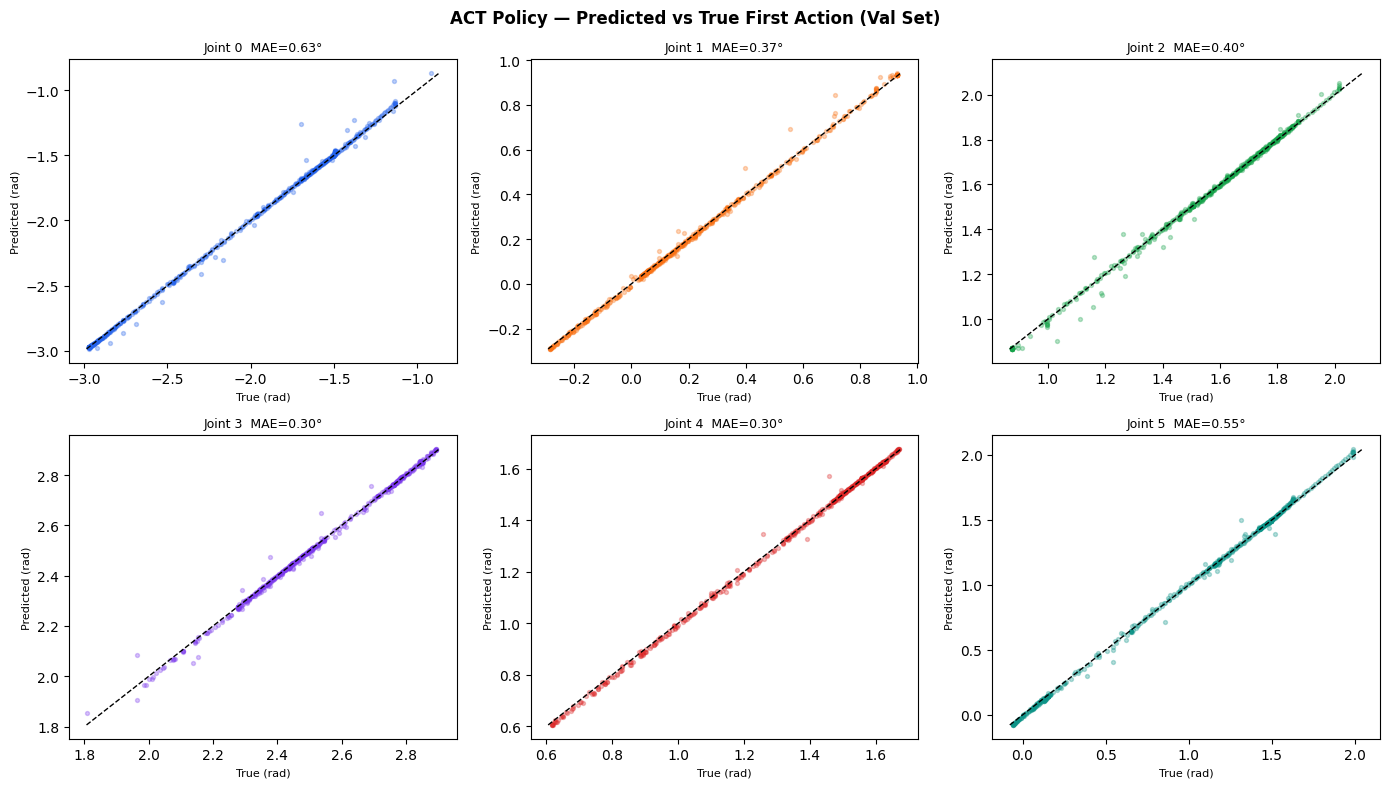

In [19]:
# Predicted vs True scatter
JCOLS = ['#2563EB','#F97316','#16A34A','#7C3AED','#DC2626','#0D9488']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('ACT Policy — Predicted vs True First Action (Val Set)',
             fontweight='bold')

for j, ax in enumerate(axes.flat):
    ax.scatter(true_np[:500, j], pred_np[:500, j],
               alpha=0.3, s=8, color=JCOLS[j])
    lo = min(true_np[:, j].min(), pred_np[:, j].min())
    hi = max(true_np[:, j].max(), pred_np[:, j].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title(f'Joint {j}  MAE={np.degrees(mae_per_joint[j]):.2f}°',
                 fontsize=9)
    ax.set_xlabel('True (rad)', fontsize=8)
    ax.set_ylabel('Predicted (rad)', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/act_pred_vs_true.png', dpi=130, bbox_inches='tight')
plt.show()

In [20]:
#Files to download
print('\nDownload these from Drive for CoppeliaSim inference:')
for fname in ['act_best.pth',
              'act_obs_mean.npy', 'act_obs_std.npy',
              'act_act_mean.npy', 'act_act_std.npy']:
    print(f'  {SAVE_DIR}/{fname}')


Download these from Drive for CoppeliaSim inference:
  /content/drive/MyDrive/imitation_learning_training/act_checkpoints/act_best.pth
  /content/drive/MyDrive/imitation_learning_training/act_checkpoints/act_obs_mean.npy
  /content/drive/MyDrive/imitation_learning_training/act_checkpoints/act_obs_std.npy
  /content/drive/MyDrive/imitation_learning_training/act_checkpoints/act_act_mean.npy
  /content/drive/MyDrive/imitation_learning_training/act_checkpoints/act_act_std.npy
